A Regressão Linear foi nosso modelo candidato 1.

 Ela explicou aproximadamente 82,9% da variação dos preços, com erro absoluto médio de aproximadamente R$ 202 mil.
 
 Esses resultados nos dão uma primeira referência
 
 Pergunta: Regressão Linear é a melhor alternativa para esse problema?
 
 Vamos testar modelos capazes de representar relações mais complexas, como Árvore de Decisão e Random Forest, e comparar seus resultados usando as mesmas métricas.

**Teoria**

O modelo de regressão linear talvez seja simples demais, porque ele tenta em uma equação encontrar(traçar reta) uma explicação para todos os casos

Mas se essas relações forem mais complexas do que:
- Área maior → tende a aumentar o preço
- Mais quartos → tende a aumentar o preço

Mas um imóvel com determinada área pode ser mais caro ou muito mais barato dependendo da região
Então essa combinação pode não ser plenamente coberta pela regressão.

Na atividade anterior vimos que o modelo errou bastante quando tentou precificar imóveis de alto padrão.


**Árvore de decisão**

Ela começa com uma pergunta qualquer em cima da informação de uma coluna e vai refinando as respostas para explicar uma situação.
Exemplo:
A **área** é maior que 200m²?
A resposta é sim ou não...dai evoluimos para outra pergunta
Os quartos são 3 ou mais?...
A região A os valores são 600k na Região B 1.2M

Ela não tenta descobrir uma formula(equação da reta) para todos os imóveis.

Na realidade existem caminhos diferentes para cada situação, então por isso nossa pergunta pode ser respondida...E se exitem relações mais complexas?!

                 área_m2 > 200?
                   /       \
                 NÃO       SIM
                 /           \
       quartos > 3?       localidade?
         /    \             /     \
       não    sim       Região A  Região B
        ↓      ↓           ↓         ↓
      400k    550k        800k      1,2M

**Agrupamentos**

Considerando nossa base de dados o exemplo acima gera grupos
Se a area é maior que 200m, então o grupo desses imóveis está no grupo1(podemos chamar de maiores)
Se a area é menor que 200m , então temos outro grupo2(menores)

Então esses grupos são divididos novamente em outra pergunta ( são menores ou iguais a 3 quartos?)

No final o agrupamento é para criar os grupos mais semelhantes

Ao final, o que é chamado de folha(leaf) é justamente o caminho aprendido para gerar o resutltado

Por exemplo: Area maior que 200m com 3 quartos na Asa sul é o caminho que leva até a folha de preço estimado de 1.15M

**Comparando os modelos**
Vamos utilizar os mesmos dados, com o mesmo tratamento para fazer uma comparação correta


                  MESMOS DADOS
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
     Linear        Árvore       Random Forest
          │            │            │
          ↓            ↓            ↓
       métricas     métricas     métricas

**Releitura da base_imoveis.csv**


In [28]:
#Importanto bibliotecas e lendo a base de dados
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

df =pd.read_csv(r'C:\Users\marciohenrique\Documents\Projetos\github\ml_stat\bases_dados\base_imoveis.csv')

**Releitura das variaveis tratadas**

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # O pipeline garante que as mesmas transformações utilizadas no treinamento sejam aplicadas aos novos imóveis posteriormente.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

features = [
    "localidade",
    "tipo",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

target = "preco_venda"

numeric_features = [
    "area_m2",
    "quartos",
    "banheiros",
    "vagas_garagem",
    "idade_anos"
]

categorical_features = [
    "localidade",
    "tipo"
]

df = df.dropna(subset=["preco_venda"]).copy() #Dropando nulos da variavel y

#Tratamento numerico
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")) # vamos usar a mediana para tratar os nulos numéricos
    ]
)

#tratamento categorico
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), #aqui usamos a moda para imputar o mais frequente p/ substituir nulos
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

X = df[features]
y = df[target]

#Juntanto todo o processo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Importando o modelo DECISION TREE**\
também junto vamos executar tudo via pipeline como na Regressão Linear

In [55]:
from sklearn.tree import DecisionTreeRegressor
modelo_arvore = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=None,
                random_state=42
            )
        )
    ]
)

#max_depth=15

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['localidade','tipo','area_m2',...,'banheiros','vagas_garagem', 'idade_anos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of col

In [57]:
y_pred_arvore = modelo_arvore.predict(X_test)

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_arvore = mean_absolute_error(
    y_test,
    y_pred_arvore
)

rmse_arvore = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_arvore
    )
)

r2_arvore = r2_score(
    y_test,
    y_pred_arvore
)

print(f"MAE: R$ {mae_arvore:,.2f}")
print(f"RMSE: R$ {rmse_arvore:,.2f}")
print(f"R²: {r2_arvore:.4f}")

MAE: R$ 198,775.52
RMSE: R$ 338,648.33
R²: 0.8196


**Considerações Importantes**

Sobre o depth:
É a profundiade máxima da árvore, ou seja a disntancia entre a raiz(pergunta inicial) e as folhas (resultado final)
Em outras palavras é nível de agrupamento ou perguntas antes da tomada de decisão.

A cada nível a árvore refina/divide os dados em grupos cada vez menores e mais específicos

*Nível baixo*: Poucos grupos, mas grandes demais, resultando numa árvore generalista demais. **UNDERFITING (Subajuste)**

*Nível alto*: Muitos grupos, mas pequenos demais, muito específicos, resultado numa árvore que não aprende a generalizar, mas decora as linhas de treino **(OVERFITING)**


**Pergunta**

Qual dos dois modelos se saiu melhor?
O modelo de árvore é Ruim ? Qual a justificativa

**Adicionando a variavel arvore para plotar o gráfico da arvore**

In [34]:
arvore = modelo_arvore.named_steps["model"]
arvore
nomes_features = modelo_arvore.named_steps[
    "preprocessor"
].get_feature_names_out()


**Visualizando a árvore de perto**

Selecionamos max_depth = 2 apenas para tornar mais visível\
**Não foi alterado o max_deph de treinamento**

a variavel arvore foi criada antes para garantir uma copia do modelo_arvore

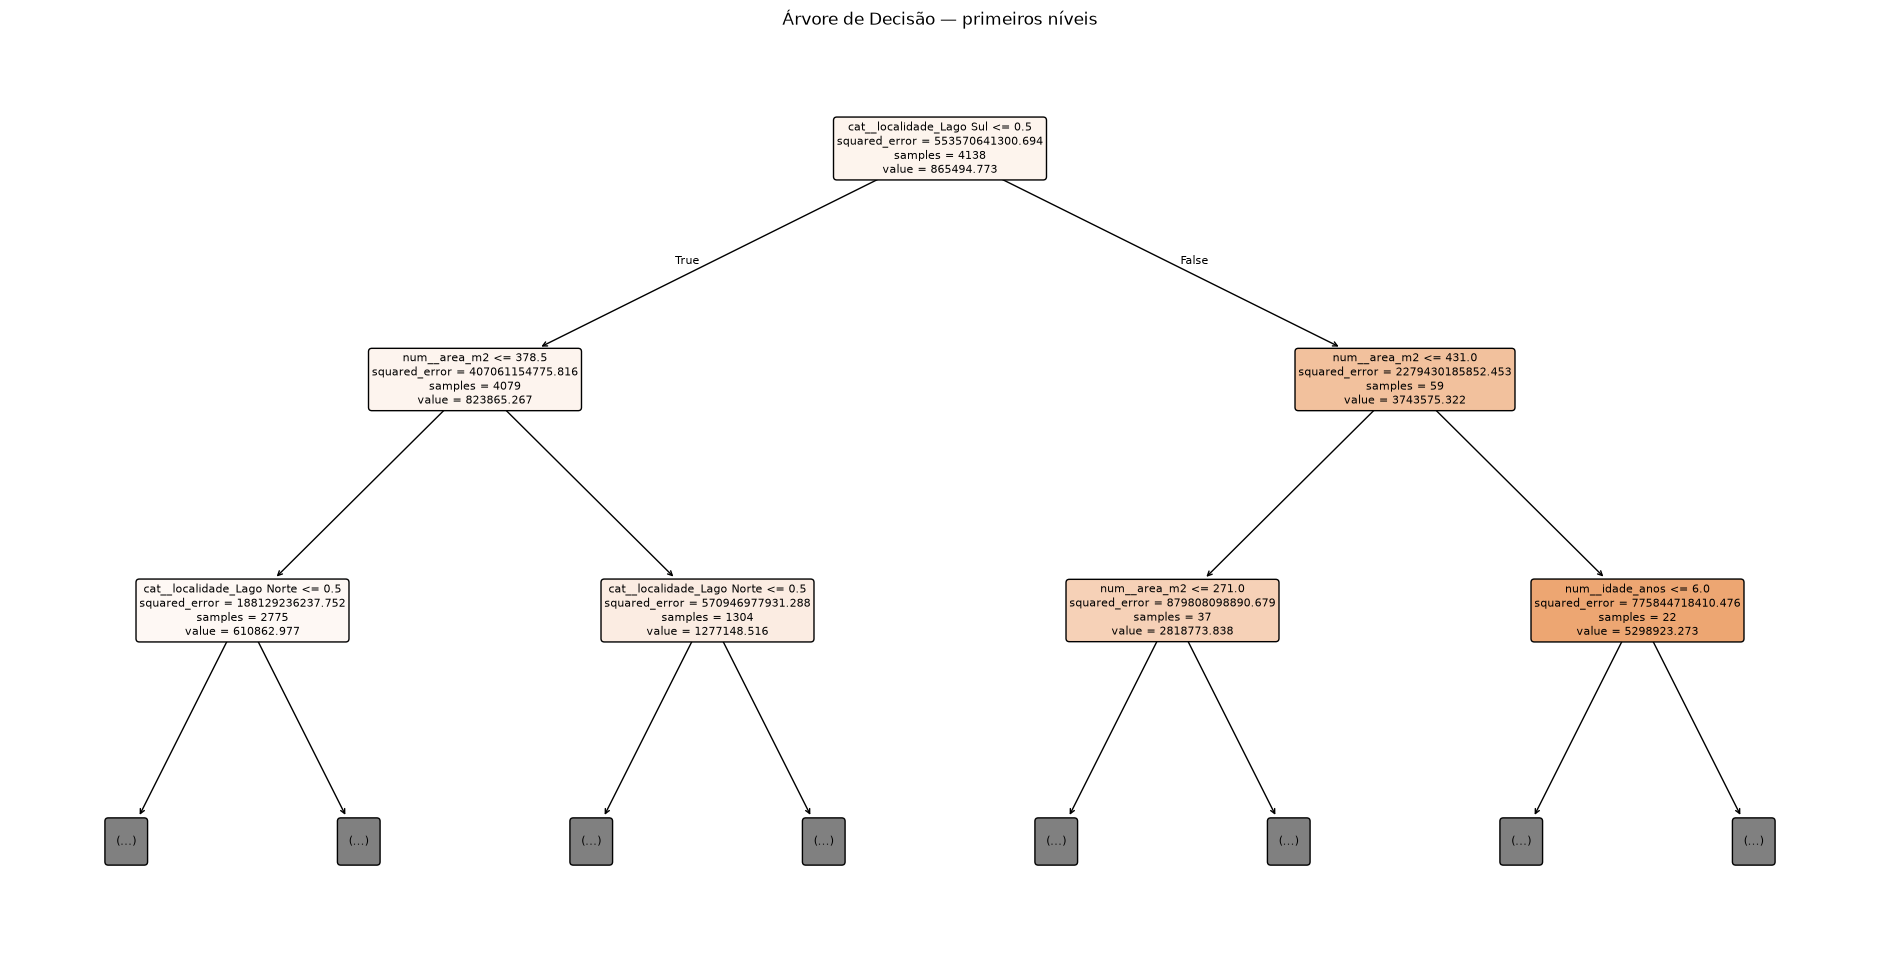

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(24, 12))

plot_tree(
    arvore,
    max_depth=2,
    feature_names=nomes_features,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árvore de Decisão — primeiros níveis")
plt.show()

**Avaliando Overfiting e Underfitting**

Porque o modelo da árvore (DECISION TREE) foi pior que o modelo de Regressão Linear?

- O indicadores MAE, RMSE e R² mostram que a média e o erro quadrado foram bem maiores na árvore e também a explicação da variância foi menor que 80%

Embora mais "sofisticado" Nõa significa que é o melhor modelo.
Precisamos atestar cada um e avaliar os indicares, além disso há o objetivo específico do negócio. ESSA É PREMISSA 

Também não siginifca dizer que ARVORE é MELHOR OU PIOR QUE RL
há uma trilha de investigação a ser feita para árvore:

- Profundidade: Altere max_depth para [3,5,10,15] há mudança significativa?
- Overfiting x Underfiting?
- Outros algoritimos
    -Random Forest
    -Gradient Boost


Os indicadores de **treino** mostram R² melhor do que no teste(previsão).
- O que isso representa? Temos overfiting?
- A diferença de explicação entre treino e teste é alta?

Analisando demais indicaores em relação ao modelo de RL...
Qual conclusão podemos chegar entre RL e DT?
**Se a Decision Tree se mostra sofrer com grandes erros, porque insistir e treinar com Random Forest?**

- A questão é: Posso combinar relações complexas com uma capacidade generalista melhor??
A Árvore de Decisão apresentou R² de 0,8384 no treinamento e 0,7688 no teste. A diferença entre esses resultados mostra que o modelo perdeu desempenho ao receber dados não utilizados no treinamento, indicando alguma perda de generalização.

Entretanto, não observamos um overfitting extremo, pois a diferença entre treino e teste não é tão grande quanto seria em um modelo fortemente sobreajustado.

No conjunto de teste, a Regressão Linear apresentou desempenho superior em todas as métricas analisadas:

- menor MAE;
- menor RMSE;
- maior R².

Portanto, a Árvore de Decisão não superou nossa referência neste experimento.
**Última provocação antes da análise de RANDOM FOREST?**\
POruqe não seguir com a árvore já que o modelo, no treinamento possui 83% de capacidade para explicar os dados?

**Análise de Treinamento**

In [59]:
y_pred_arvore_train = modelo_arvore.predict(X_train)

mae_arvore_train = mean_absolute_error(
    y_train,
    y_pred_arvore_train
)

rmse_arvore_train = np.sqrt(
    mean_squared_error(
        y_train,
        y_pred_arvore_train
    )
)

r2_arvore_train = r2_score(
    y_train,
    y_pred_arvore_train
)

print(f"Treino - MAE: R$ {mae_arvore_train:,.2f}")
print(f"Treino - RMSE: R$ {rmse_arvore_train:,.2f}")
print(f"Treino - R²: {r2_arvore_train:.4f}")

Treino - MAE: R$ 25.50
Treino - RMSE: R$ 1,160.01
Treino - R²: 1.0000


**RANDOM FOREST**

Se o modelo de decisão por árvore DECISION TREE apresenta uma árvore única, representa um corretor
Poderíamos pensar que se tivermos vários corretores avaliando um imóvel, alguns vão dizer um preço, outros vão dizer outros preços
Ao juntarmos cada corretor que avalie todos os imóveis cada resposta combinada deve chegar a um valor previsto razoável

Essa analogia é usada no modelo de árvores aleatórias ou RANDOM FOREST



In [37]:
#Importante o modelo RANDOM FOREST e inserindo o pipeline para o modelo de Random Forest
from sklearn.ensemble import RandomForestRegressor
modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=None,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

n_estimators=200 #seriam os corretores avaliando o imóvel, cada um com uma árvore de decisão diferente
n_jobs=-1 #significa que o modelo vai usar todos os núcleos do processador para treinar o modelo, tornando mais rápido o treinamento

**Novamente treinamento e teste**


In [38]:
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

In [39]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(f"MAE: R$ {mae_rf:,.2f}")
print(f"RMSE: R$ {rmse_rf:,.2f}")
print(f"R²: {r2_rf:.4f}")

MAE: R$ 153,691.23
RMSE: R$ 252,716.68
R²: 0.8995


In [40]:
resultados = pd.DataFrame({
    "Modelo": [
        #"Regressão Linear",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "MAE": [
        #mae_linear,
        mae_arvore,
        mae_rf
    ],
    "RMSE": [
        #rmse_linear,
        rmse_arvore,
        rmse_rf
    ],
    "R2": [
        #r2_linear,
        r2_arvore,
        r2_rf
    ]
})

resultados

,Modelo,MAE,RMSE,R2
0,Árvore de Decisão,259312.130173,383307.726518,0.768846
1,Random Forest,153691.229536,252716.681364,0.899521


**Comparando os 3 modelos**

| Modelo            |            MAE |           RMSE |         R² |
| ----------------- | -------------: | -------------: | ---------: |
| Regressão Linear  |     R$ 202.420 |     R$ 329.889 |     0,8288 |
| Árvore de Decisão |     R$ 259.312 |     R$ 383.308 |     0,7688 |
| **Random Forest** | **R$ 153.691** | **R$ 252.717** | **0,8995** |


**Validação Cruzada**

Cross Validation

Essa é uma análise para saber se:
Caso eu altere o padrão treinamento X teste o modelo continua sendo bom?
Outra pergunta que pode ser respondida é...Será que essa divisão 80/20 favirece determinado modelo?
